# EDA

In [21]:
# Импорты
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt


# # Показываем больше столбцов в таблицах pandas
# pd.set_option("display.max_columns", 100)
# pd.set_option("display.width", 120)

# Пути проекта
PROJECT_ROOT = Path("..")
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "UCI_Credit_Card.csv"
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "credit_card_processed.csv"
PROCESSED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

In [22]:
# Загрузка данных
df = pd.read_csv(RAW_DATA_PATH)

print("Размер датасета:", df.shape)
display(df.head())

Размер датасета: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [23]:
# Общая информация
df.info()
print(df.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   30000 non-null

In [24]:
# Пропуски и дубликаты

missing_values = df.isna().sum()
duplicates_count = df.duplicated().sum()

print("Количество пропусков по столбцам:")
display(missing_values[missing_values > 0])

print("Количество полных дубликатов:", duplicates_count)

Количество пропусков по столбцам:


Series([], dtype: int64)

Количество полных дубликатов: 0


In [25]:
# Переименование целевой переменной

TARGET_ORIGINAL = "default.payment.next.month"
TARGET = "target"
df = df.rename(columns={TARGET_ORIGINAL: TARGET})

Распределение target:


target
0    23364
1     6636
Name: count, dtype: int64

Доля классов target:


target
0    0.7788
1    0.2212
Name: proportion, dtype: float64

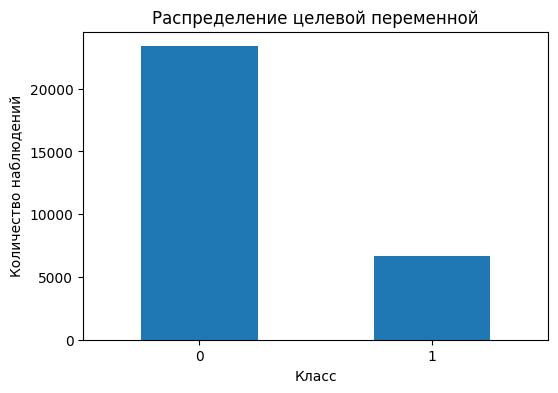

0 - нет дефолта
1 - дефолт


In [26]:
# Анализ целевой переменной
target_counts = df[TARGET].value_counts()
target_share = df[TARGET].value_counts(normalize=True)

print("Распределение target:")
display(target_counts)

print("Доля классов target:")
display(target_share)

plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")
plt.title("Распределение целевой переменной")
plt.xlabel("Класс")
plt.ylabel("Количество наблюдений")
plt.xticks(rotation=0)
plt.show()

print("0 - нет дефолта")
print("1 - дефолт")

In [27]:
# Описательная статистика
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


In [28]:
# делю на группы признаков
id_column = "ID"
categorical_columns = ["SEX", "EDUCATION", "MARRIAGE",]
payment_status_columns = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",]
bill_amount_columns = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",]
payment_amount_columns = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6",]
base_numeric_columns = ["LIMIT_BAL", "AGE",]
print("Категориальные признаки:", categorical_columns)
print("Признаки статуса платежей:", payment_status_columns)
print("Признаки суммы счетов:", bill_amount_columns)
print("Признаки суммы платежей:", payment_amount_columns)
print("Базовые числовые признаки:", base_numeric_columns)

Категориальные признаки: ['SEX', 'EDUCATION', 'MARRIAGE']
Признаки статуса платежей: ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
Признаки суммы счетов: ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
Признаки суммы платежей: ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
Базовые числовые признаки: ['LIMIT_BAL', 'AGE']


In [29]:
# Анализ категориальных признаков
for column in categorical_columns:
    print(f"Распределение признака {column}:")
    display(df[column].value_counts().sort_index())

Распределение признака SEX:


SEX
1    11888
2    18112
Name: count, dtype: int64

Распределение признака EDUCATION:


EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

Распределение признака MARRIAGE:


MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

In [30]:
# Значения EDUCATION 4=others, 5=unknown, 6=unknown объединяю в группу others

df_clean = df.copy()
df_clean["EDUCATION"] = df_clean["EDUCATION"].replace({0: 4, 5: 4, 6: 4})

# Значения MARRIAGE 0 в группу others:
df_clean["MARRIAGE"] = df_clean["MARRIAGE"].replace({0: 3})

print("Распределение EDUCATION после коррекции:")
display(df_clean["EDUCATION"].value_counts().sort_index())
print("Распределение MARRIAGE после коррекции:")
display(df_clean["MARRIAGE"].value_counts().sort_index())

Распределение EDUCATION после коррекции:


EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

Распределение MARRIAGE после коррекции:


MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64

In [31]:
# Анализ статуса платежей
for column in payment_status_columns:
    print(f"Распределение признака {column}:")
    display(df_clean[column].value_counts().sort_index())

Распределение признака PAY_0:


PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

Распределение признака PAY_2:


PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

Распределение признака PAY_3:


...

PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

Распределение признака PAY_5:


PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

Распределение признака PAY_6:


PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype: int64

Подавляющее большенство платежей без задержек

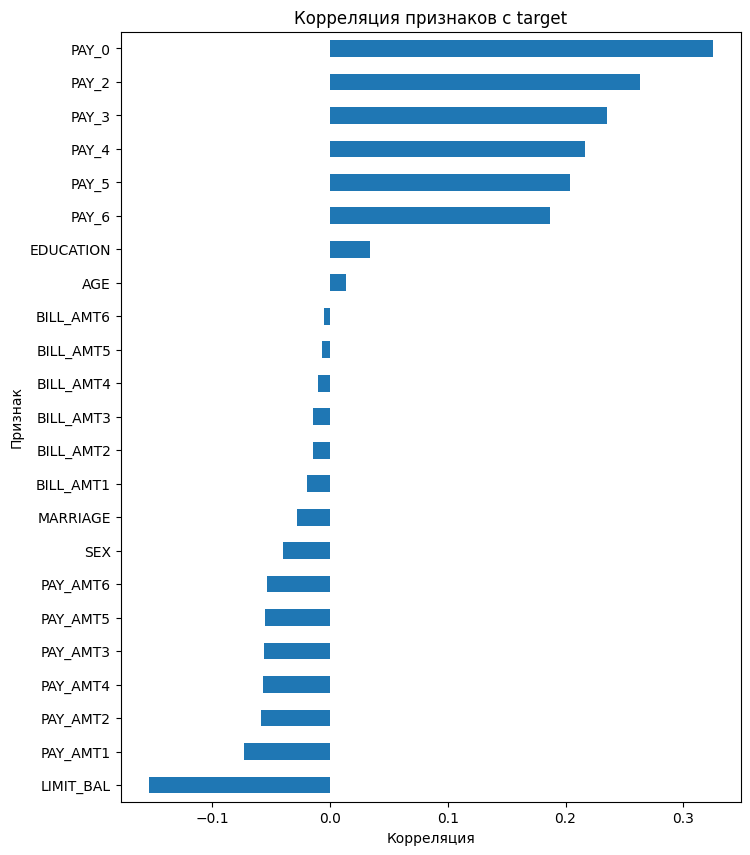

In [32]:
# Корреляция признаков с target
correlation_with_target = (
    df_clean
    .drop(columns=[id_column])
    .corr(numeric_only=True)[TARGET]
    .sort_values(ascending=False)
)
plt.figure(figsize=(8, 10))
correlation_with_target.drop(TARGET).sort_values().plot(kind="barh")
plt.title("Корреляция признаков с target")
plt.xlabel("Корреляция")
plt.ylabel("Признак")
plt.show()

In [33]:
# Подготовка финального датасета
# Удаляю ID 
df_processed = df_clean.copy()
df_processed = df_processed.drop(columns=["ID"])

print("Размер финального датасета:", df_processed.shape)

Размер финального датасета: (30000, 24)


In [34]:
# Финальная проверка данных
print("Размер финального датасета:", df_processed.shape)
print(f"Количество пропусков: {df_processed.isna().sum().sum()}")
print(f"Количество дубликатов: {df_processed.duplicated().sum()}")
print("Типы данных:")
display(df_processed.dtypes)
print("Распределение target:")
display(df_processed["target"].value_counts(normalize=True))

Размер финального датасета: (30000, 24)
Количество пропусков: 0
Количество дубликатов: 35
Типы данных:


LIMIT_BAL    float64
SEX            int64
EDUCATION      int64
MARRIAGE       int64
AGE            int64
PAY_0          int64
PAY_2          int64
PAY_3          int64
PAY_4          int64
PAY_5          int64
PAY_6          int64
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float64
PAY_AMT3     float64
PAY_AMT4     float64
PAY_AMT5     float64
PAY_AMT6     float64
target         int64
dtype: object

Распределение target:


target
0    0.7788
1    0.2212
Name: proportion, dtype: float64

In [35]:
# Сохранение подготовленного датасета
df_processed.to_csv(PROCESSED_DATA_PATH, index=False)

## Итог EDA

В ходе анализа был изучен датасет кредитных клиентов UCI Credit Card.

Основные результаты:

- датасет содержит 30 000 наблюдений
- целевая переменная **target** является бинарной
- задача относится к бинарной классификации
- пропуски в данных отсутствуют
- технический столбец **ID** удалён
- редкие и неявные значения в признаках **EDUCATION** и **MARRIAGE** были объединены в категорию **others**
- feature engineering не выполнялся, чтобы API мог принимать исходные признаки клиента

Подготовленый датасет будет используется в **src/train_model.py** для обучения моделей